# Approximate Bayesian computation

Besides its neural estimators, `sbijax` implements two approximate Bayesian computation (ABC) samplers:

- `smcabc`: sequential Monte Carlo ABC (Beaumont et al., 2009),
- `sabc`: simulated annealing ABC (Albert et al., 2025).

Neither trains a network, so there is no `simulate`/`train` step. You build a sampler from the prior and the simulator, and call its `sample` method with an observation:

```python
sampler = sabc(prior, simulator_fn, summary_fn, distance_fn)  # or smcabc(prior, simulator_fn)
samples, info = sampler.sample(rng_key, y_observed, **settings)
```

`samples` is a pytree named after the prior with leaves of shape `(1, n_particles, dim)`, the same layout the other methods return. The simulations happen inside `sample`, so each call runs the whole algorithm for one observation.

In [1]:
import jax
from jax import numpy as jnp, random as jr
from tensorflow_probability.substrates.jax import distributions as tfd

from sbijax import sabc, smcabc

%matplotlib inline
import matplotlib.pyplot as plt

## Model

We use a bivariate Gaussian model whose posterior is known in closed form:

\begin{align}
\theta &\sim \mathcal{N}_2(0, I)\\
y \mid \theta &\sim \mathcal{N}_2(\theta, \sigma^2 I)
\end{align}

with $\sigma = 0.5$. The posterior is $\mathcal{N}_2\left(\frac{y}{1 + \sigma^2}, \frac{\sigma^2}{1 + \sigma^2} I\right)$.

The prior and the simulator follow the same rules as for the neural methods: every distribution in the prior is vector-valued, and the simulator is called as `simulator_fn(seed=..., theta=...)` with a batch of parameters and returns a matrix of shape `(n, d)`.

In [2]:
sigma = 0.5

prior = tfd.JointDistributionNamed(
  dict(theta=tfd.Normal(jnp.zeros(2), 1.0)), batch_ndims=0
)


def simulator_fn(seed, theta):
  noise = tfd.Normal(jnp.zeros_like(theta["theta"]), sigma)
  return theta["theta"] + noise.sample(seed=seed)


y_observed = jnp.array([-1.0, 1.0])
posterior = tfd.Normal(y_observed / (1 + sigma**2), jnp.sqrt(sigma**2 / (1 + sigma**2)))

## Sequential Monte Carlo ABC

`smcabc` needs a summary function, which maps simulated and observed data to summary statistics, and a distance between summaries. The distance must return one value per simulation, i.e. an array of shape `(n,)` or `(n, 1)` such as the one `sbijax.l2_distance` returns. Here the data are already low-dimensional, so the summary is the identity and the distance is Euclidean.

The sampler starts from `n_particles` prior draws and runs `n_rounds` rounds. Each round lowers the tolerance by the factor `eps_step`, perturbs the particles, simulates, and keeps the particles whose distance falls below the tolerance, weighting them by prior over proposal density. When the effective sample size drops below `ess_min`, and always in the last round, the particles are resampled, so the returned particles are equally weighted posterior draws.

In [3]:
def summary_fn(y):
  return y


def distance_fn(y_simulated, y_observed):
  return jnp.linalg.norm(y_simulated - y_observed, axis=-1)


sampler = smcabc(prior, simulator_fn, summary_fn, distance_fn)
smc_samples, smc_info = sampler.sample(
  jr.key(1), y_observed, n_rounds=10, n_particles=2_000, eps_step=0.8, ess_min=1_000
)
print("simulations used:", int(smc_info.n_simulations[-1]))

100%|████████████████████████████████████████████████████████████████████| 10/10 [01:33<00:00,  9.40s/it]

simulations used: 66861


## Simulated annealing ABC

`sabc` anneals a population of `n_particles` particles towards the posterior until the simulation budget `n_simulation` is spent. Its default summary is the identity and its default distance, `abs_distance`, returns one distance per summary statistic. With the default schedule `SingleEps()` all statistics share one tolerance; `MultiEps()` gives each statistic its own, which helps when some statistics are uninformative (Albert et al., 2025).

In [4]:
sampler = sabc(prior, simulator_fn)
sabc_samples, sabc_info = sampler.sample(
  jr.key(2), y_observed, n_particles=2_000, n_simulation=200_000, 
)
print("final tolerance:", sabc_info.epsilon_history[-1])

final tolerance: [0.015983]


## Comparison with the exact posterior

Both samplers approximate the posterior only up to their final tolerance. Here the SMC-ABC particles are about 10% wider than the exact posterior, and the SABC particles are shifted towards the observation.

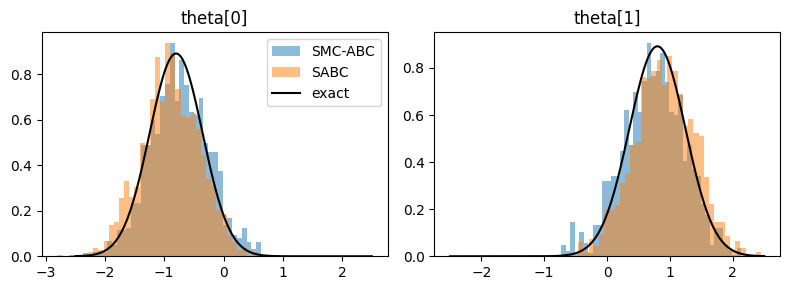

In [5]:
grid = jnp.linspace(-2.5, 2.5, 200)
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for i, ax in enumerate(axes):
  ax.hist(smc_samples["theta"][0, :, i], bins=40, density=True, alpha=0.5, label="SMC-ABC")
  ax.hist(sabc_samples["theta"][0, :, i], bins=40, density=True, alpha=0.5, label="SABC")
  ax.plot(grid, jnp.exp(posterior[i].log_prob(grid)), color="black", label="exact")
  ax.set_title(f"theta[{i}]")
axes[0].legend()
fig.tight_layout()

In [6]:
for name, samples in [("SMC-ABC", smc_samples), ("SABC", sabc_samples)]:
  theta = samples["theta"][0]
  print(f"{name:8s} mean {theta.mean(0)}, std {theta.std(0)}")
print(f"{'exact':8s} mean {posterior.mean()}, std {posterior.stddev()}")

SMC-ABC  mean [-0.74411386  0.73336655], std [0.49410242 0.50111437]
SABC     mean [-0.89236367  0.90451044], std [0.48551512 0.4869395 ]
exact    mean [-0.8  0.8], std [0.4472136 0.4472136]


## One tolerance per summary statistic

When some summary statistics carry no information about the parameters, a single shared tolerance lets their noise dominate the distance. `MultiEps` gives each statistic its own tolerance instead. It needs a distance with one value per statistic, of shape `(n, s)`, which `abs_distance`, the default distance of `sabc`, returns. The schedule is an argument of `sample`.

We use the mixture model with distractors of Albert et al. (2025), available as `sbijax.simulators.mixture_model_with_distractors`. Its parameter $\theta \sim \mathcal{U}(-10, 10)$ enters only the first two of ten statistics; the other eight are standard normal noise. The model also comes with its likelihood, which gives the exact posterior on a grid.

For comparison, we also run SMC-ABC with the Euclidean distance over all ten statistics, which has the same single tolerance as `SingleEps`.

In [7]:
from sbijax import MultiEps, SingleEps, l2_distance
from sbijax.simulators import mixture_model_with_distractors

prior, simulator_fn, likelihood = mixture_model_with_distractors()
y_observed = simulator_fn(jr.key(0), {"theta": jnp.array([[2.0]])})

The prior is uniform, so the exact posterior is the likelihood, normalised over a grid of $\theta$ values.

In [8]:
grid = jnp.linspace(-10.0, 10.0, 4001)
log_lik = likelihood(jnp.repeat(y_observed, grid.shape[0], 0), {"theta": grid[:, None]})
exact = jnp.exp(log_lik - log_lik.max())
exact = exact / (exact.sum() * (grid[1] - grid[0]))

SABC with a shared tolerance and with one tolerance per statistic, on the same simulation budget:

In [9]:
sampler = sabc(prior, simulator_fn)
single_samples, _ = sampler.sample(
  jr.key(1), y_observed, schedule=SingleEps(), n_particles=1_000, n_simulation=100_000
)
multi_samples, multi_info = sampler.sample(
  jr.key(1), y_observed, schedule=MultiEps(), n_particles=1_000, n_simulation=100_000
)
print("final tolerance per statistic:", multi_info.epsilon_history[-1])

final tolerance per statistic: [0.06805384 0.04729282 0.6964889  0.99718565 1.5996647  4.0028267
 5.1427646  0.749566   0.56402886 0.6341699 ]


SMC-ABC with the Euclidean distance over all ten statistics:

In [10]:
smc_sampler = smcabc(prior, simulator_fn, lambda y: y, l2_distance)
smc_samples, smc_info = smc_sampler.sample(
  jr.key(1), y_observed, n_rounds=5, n_particles=1_000, eps_step=0.8, ess_min=1_000
)
print("simulations used:", int(smc_info.n_simulations[-1]))

100%|██████████████████████████████████████████████████████████████████████| 5/5 [00:41<00:00,  8.39s/it]

simulations used: 10936


posterior std: SingleEps 3.00, MultiEps 2.29, SMC-ABC 2.44, exact 2.23


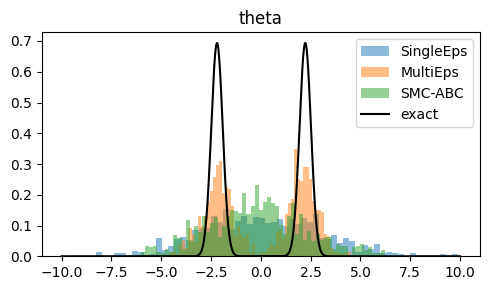

In [11]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(single_samples["theta"][0, :, 0], bins=60, density=True, alpha=0.5, label="SingleEps")
ax.hist(multi_samples["theta"][0, :, 0], bins=60, density=True, alpha=0.5, label="MultiEps")
ax.hist(smc_samples["theta"][0, :, 0], bins=60, density=True, alpha=0.5, label="SMC-ABC")
ax.plot(grid, exact, color="black", label="exact")
ax.set_title("theta")
ax.legend()
fig.tight_layout()

exact_mean = jnp.sum(grid * exact) * (grid[1] - grid[0])
exact_std = jnp.sqrt(jnp.sum((grid - exact_mean) ** 2 * exact) * (grid[1] - grid[0]))
print(f"posterior std: SingleEps {single_samples['theta'].std():.2f}, "
      f"MultiEps {multi_samples['theta'].std():.2f}, "
      f"SMC-ABC {smc_samples['theta'].std():.2f}, exact {exact_std:.2f}")

The posterior has one mode for each sign of $\theta$. With one tolerance per statistic, the SABC particles concentrate on the two modes, each about twice as wide as in the exact posterior. With a single tolerance, in SABC with `SingleEps` and in SMC-ABC with the Euclidean distance, the distractors keep the particles spread over the whole range around and between the modes. SMC-ABC used far fewer simulations here (about 22,000, against 400,000 per SABC run).

## SABC diagnostics

Next to the particles, `sample` returns a record with three fields:

- `epsilon_history`: the tolerance after each update, with one column per tolerance, i.e. one for `SingleEps` and one per statistic for `MultiEps`. SABC anneals the tolerances towards zero at a speed set by the schedule's `v`; once the curves flatten out, more simulations change the particles little.
- `u_history`: after each update, the mean over the particles of $u$, where $u$ is a particle's distance mapped through the empirical distribution of the distances of the initial prior draws. So $u \in [0, 1]$ is the fraction of prior simulations that came closer to the observation than the particle, one value per statistic.
- `rho`: the distances of the final particles, one column per statistic.

Below are the tolerances, the mean $u$ and the final distances of the `MultiEps` run above, with the two informative statistics in colour and the eight distractors in grey.

final mean u per statistic: [0.072      0.05       0.395      0.42900002 0.45900002 0.49
 0.49500003 0.40300003 0.37       0.384     ]
median final distance per statistic: [0.48       0.41       1.02       0.53999996 0.59       0.96999997
 0.64       0.71       0.42       1.41      ]


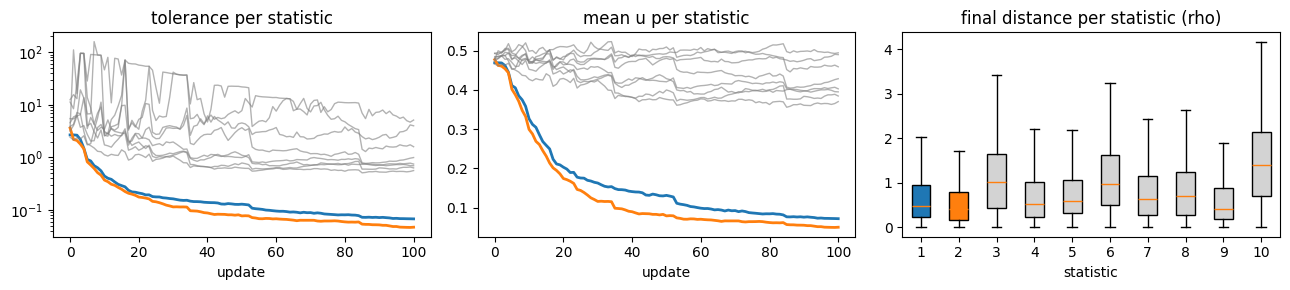

In [12]:
n_stats = multi_info.epsilon_history.shape[1]
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for i in range(n_stats):
  style = dict(color=f"C{i}", lw=2) if i < 2 else dict(color="grey", lw=1, alpha=0.6)
  axes[0].plot(multi_info.epsilon_history[:, i], **style)
  axes[1].plot(multi_info.u_history[:, i], **style)
axes[0].set_yscale("log")
axes[0].set_title("tolerance per statistic")
axes[1].set_title("mean u per statistic")
for ax in axes[:2]:
  ax.set_xlabel("update")
boxes = axes[2].boxplot(multi_info.rho, showfliers=False, patch_artist=True)
for i, box in enumerate(boxes["boxes"]):
  box.set_facecolor(f"C{i}" if i < 2 else "lightgrey")
axes[2].set_title("final distance per statistic (rho)")
axes[2].set_xlabel("statistic")
fig.tight_layout()

print("final mean u per statistic:", multi_info.u_history[-1].round(3))
print("median final distance per statistic:", jnp.median(multi_info.rho, axis=0).round(2))

The tolerances and mean $u$ of the two informative statistics fall steadily, to about 0.03 and 0.04, and are still decreasing when the simulation budget runs out. Those of the distractors stay near their starting level, with a mean $u$ of about 0.4, close to the 0.5 of distances that do not depend on $\theta$. The final distances show the same split: the informative statistics end at a median distance of about 0.3, while each distractor keeps the distance between standard normal noise and its observed value, which no parameter value can reduce; it is largest where the observed value lies far from zero (statistics 3 and 10). So the diagnostics show which statistics the parameters explain, and whether the budget was large enough for the tolerances to settle.

## Session info

In [13]:
import session_info

session_info.show(html=False)

-----
jax                         0.11.2
jaxlib                      0.11.2
matplotlib                  3.10.8
sbijax                      0.4.1
session_info                v1.0.1
tensorflow_probability      0.26.0-dev20260318
-----
IPython             9.11.0
jupyter_client      8.8.0
jupyter_core        5.9.1
jupyterlab          4.5.6
notebook            7.5.5
-----
Python 3.12.10 (main, May 30 2025, 05:53:56) [Clang 20.1.4 ]
macOS-26.2-arm64-arm-64bit
-----
Session information updated at 2026-09-28 18:45
